# Classification - Example
In this script we demonstrate how a Machine Learning workflow can look like when you use a train, validation and test set. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn  import svm

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Loading Data

In [2]:
# This code is merely executed to see the description and target names in a smooth way
iris = load_iris()

In [3]:
 print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [11]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

## Storing/Loading the data in the way it will be used

In [12]:
X, y = load_iris(return_X_y=True, as_frame=True)

# Only choose two variables for my model
X = X[['sepal length (cm)', 'sepal width (cm)']]

In [13]:
print(X.info())

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
dtypes: float64(2)
memory usage: 2.5 KB
None


In [14]:
print(y.info())

<class 'pandas.Series'>
RangeIndex: 150 entries, 0 to 149
Series name: target
Non-Null Count  Dtype
--------------  -----
150 non-null    int64
dtypes: int64(1)
memory usage: 1.3 KB
None


# Train, Validation, and Test Set

In [15]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=40)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.3, random_state=36)

# EDA
We are only allowed to explore / learn things on the training data when creating our model. 

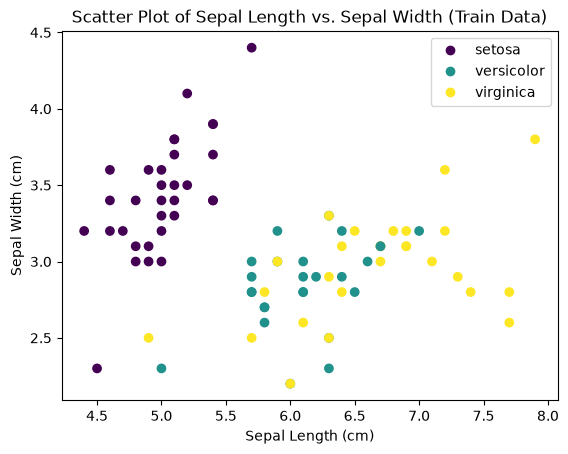

In [16]:
classes = ['setosa', 'versicolor', 'virginica']
scatter = plt.scatter(X_train['sepal length (cm)'], X_train['sepal width (cm)'], c=y_train)
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.title('Scatter Plot of Sepal Length vs. Sepal Width (Train Data)')
plt.legend(handles=scatter.legend_elements()[0], labels=classes)

In [17]:
X_train.head()

,sepal length (cm),sepal width (cm)
72,6.3,2.5
62,6.0,2.2
74,6.4,2.9
19,5.1,3.8
93,5.0,2.3


In [18]:
y_train.head()

72    1
62    1
74    1
19    0
93    1
Name: target, dtype: int64

In [19]:
# 0 = 'setosa', 1 = 'versicolor', 2 = 'virginica'
y_train.value_counts()

target
0    32
1    26
2    26
Name: count, dtype: int64

# Training 2 different models

In [20]:
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
log_reg_pred = log_reg.predict(X_val)

In [21]:
tree_clf = DecisionTreeClassifier()

# Finding the best hyperparameter through GridSearch.
hyper_params = {'max_depth':(None, 1, 2, 5, 10)}
clf = GridSearchCV(tree_clf, hyper_params)

clf.fit(X_train, y_train)
clf_pred = clf.predict(X_val)

In [22]:
print(clf.best_params_)
pd.DataFrame(clf.cv_results_)

{'max_depth': 2}


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.004176,0.003279,0.002247,0.000911,None,{'max_depth': None},0.588235,0.647059,0.764706,0.764706,0.6250,0.677941,0.073294,3
1,0.001332,0.000239,0.001424,0.000405,1,{'max_depth': 1},0.647059,0.705882,0.705882,0.647059,0.5625,0.653676,0.052634,5
2,0.001468,0.000240,0.001746,0.000631,2,{'max_depth': 2},0.764706,0.647059,0.823529,0.882353,0.6250,0.748529,0.099349,1
3,0.001189,0.000058,0.001326,0.000335,5,{'max_depth': 5},0.705882,0.647059,0.823529,0.823529,0.5625,0.712500,0.101471,2
4,0.001114,0.000073,0.000972,0.000045,10,{'max_depth': 10},0.529412,0.647059,0.764706,0.764706,0.6250,0.666176,0.089646,4


## Choosing the best model through validation set

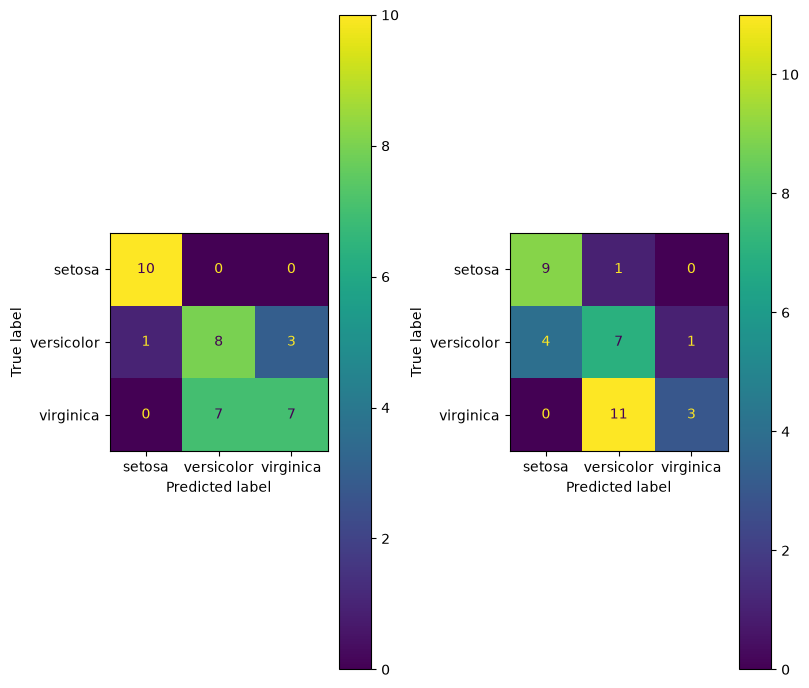

In [23]:
# These names were obtained above
target_names_iris = ['setosa', 'versicolor', 'virginica']

cm1 = confusion_matrix(y_val, log_reg_pred)
cm2 = confusion_matrix(y_val, clf_pred)

fig, axs = plt.subplots(1, 2, figsize = (8, 7), layout='constrained')
ConfusionMatrixDisplay(cm1, display_labels = target_names_iris).plot(ax=axs[0])
ConfusionMatrixDisplay(cm2, display_labels = target_names_iris).plot(ax=axs[1])

In [24]:
print(classification_report(y_val, log_reg_pred, target_names=target_names_iris))

              precision    recall  f1-score   support

      setosa       0.91      1.00      0.95        10
  versicolor       0.53      0.67      0.59        12
   virginica       0.70      0.50      0.58        14

    accuracy                           0.69        36
   macro avg       0.71      0.72      0.71        36
weighted avg       0.70      0.69      0.69        36



In [25]:
print(classification_report(y_val, clf_pred, target_names=target_names_iris))

              precision    recall  f1-score   support

      setosa       0.69      0.90      0.78        10
  versicolor       0.37      0.58      0.45        12
   virginica       0.75      0.21      0.33        14

    accuracy                           0.53        36
   macro avg       0.60      0.57      0.52        36
weighted avg       0.61      0.53      0.50        36



# Evaluating chosen model through test set

The results are extremely good since this is a "toy dataset". In reality we do not expect numbers that are as perfect as those below. 

In [53]:
# Now we retrain our model on the train + validation data. 
log_reg_final = LogisticRegression().fit(X_train_full, y_train_full)
pred_test = log_reg_final.predict(X_test)

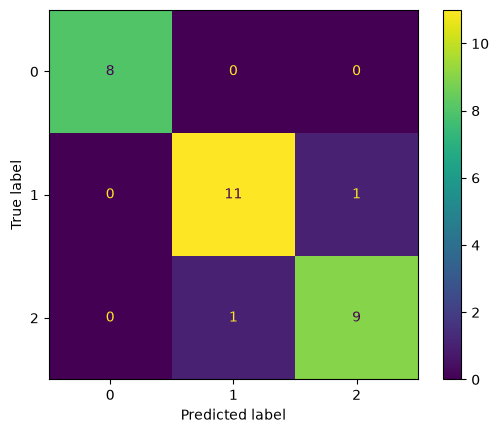

In [27]:
cm_test = confusion_matrix(y_test, pred_test)
ConfusionMatrixDisplay(cm_test).plot()

In [28]:
print(classification_report(y_test, pred_test, target_names=target_names_iris))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         8
  versicolor       0.92      0.92      0.92        12
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.94      0.94      0.94        30
weighted avg       0.93      0.93      0.93        30



# Add a random forest and SVM model (use GridSearch in both cases) to the modelling flow. 
Explain in short how the models works and what you have done. 

RandomForestClassifier:

In [38]:
RandomForest = RandomForestClassifier()

# Finding the best hyperparameter through GridSearch.
hyper_params = {'max_depth':[None, 1, 2, 5, 10],
                'n_estimators':[10, 50, 100],
                'criterion':['gini', 'entropy'],
                'min_samples_split':[2, 5, 10]
                }
ran = GridSearchCV(RandomForest, hyper_params,cv=5,n_jobs =1, verbose =1,scoring='accuracy')

ran.fit(X_train,y_train)
ran_pred = ran.predict(X_val)

Fitting 5 folds for each of 90 candidates, totalling 450 fits


In [39]:
print("best param:",ran.best_params_)

best param: {'criterion': 'gini', 'max_depth': 2, 'min_samples_split': 2, 'n_estimators': 50}


In [42]:
print("accuracy = ", ran.score(X_val,y_val))

accuracy =  0.5277777777777778


In [36]:
pd.DataFrame(ran.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_min_samples_split,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.020651,0.003764,0.003781,0.001101,gini,None,2,10,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.647059,0.588235,0.705882,0.764706,0.5625,0.653676,0.074421,79
1,0.044810,0.004110,0.003559,0.000239,gini,None,2,50,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.529412,0.588235,0.764706,0.764706,0.6250,0.654412,0.095078,75
2,0.078904,0.001647,0.005380,0.000605,gini,None,2,100,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.588235,0.588235,0.764706,0.764706,0.6250,0.666176,0.081561,66
3,0.010545,0.000592,0.002515,0.000475,gini,None,5,10,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.705882,0.588235,0.823529,0.823529,0.6250,0.713235,0.097769,23
4,0.050543,0.003525,0.004427,0.000570,gini,None,5,50,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.588235,0.588235,0.823529,0.764706,0.6250,0.677941,0.097592,54
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,0.039410,0.000577,0.003507,0.000406,entropy,10,5,50,"{'criterion': 'entropy', 'max_depth': 10, 'min...",0.529412,0.588235,0.764706,0.764706,0.6250,0.654412,0.095078,75
86,0.079221,0.002830,0.005519,0.000133,entropy,10,5,100,"{'criterion': 'entropy', 'max_depth': 10, 'min...",0.588235,0.588235,0.823529,0.764706,0.6250,0.677941,0.097592,54
87,0.009198,0.000388,0.001818,0.000108,entropy,10,10,10,"{'criterion': 'entropy', 'max_depth': 10, 'min...",0.588235,0.529412,0.823529,0.764706,0.7500,0.691176,0.112382,36
88,0.040463,0.001533,0.003241,0.000257,entropy,10,10,50,"{'criterion': 'entropy', 'max_depth': 10, 'min...",0.647059,0.588235,0.882353,0.823529,0.6250,0.713235,0.117094,23


# svm support vector machine

class sklearn.svm.SVC(*, C=1.0, kernel='rbf', degree=3, gamma='scale', coef0=0.0, shrinking=True, probability='deprecated', tol=0.001, cache_size=200, class_weight=None, verbose=False, max_iter=-1, decision_function_shape='ovr', break_ties=False, random_state=None)[source]


In [47]:
sm_clf = svm.SVC()
# Finding the best hyperparameter through GridSearch.
hyper_params = {
                'gamma':['scale'],
                'kernel':['linear', 'poly', 'rbf','sigmoid']
                }
sm = GridSearchCV(sm_clf, hyper_params,cv=5,n_jobs =1, verbose =1,scoring='accuracy')

sm.fit(X_train,y_train)


Fitting 5 folds for each of 4 candidates, totalling 20 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'gamma': ['scale'], 'kernel': ['linear', 'poly', ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection st

In [48]:
print(ran.best_params_)

{'criterion': 'gini', 'max_depth': 2, 'min_samples_split': 2, 'n_estimators': 50}


In [49]:
pd.DataFrame(ran.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_min_samples_split,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.015112,0.004758,0.003286,0.001037,gini,None,2,10,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.647059,0.588235,0.764706,0.764706,0.5625,0.665441,0.085560,70
1,0.051275,0.008352,0.004371,0.000785,gini,None,2,50,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.588235,0.588235,0.764706,0.764706,0.6250,0.666176,0.081561,62
2,0.091731,0.010810,0.006784,0.001225,gini,None,2,100,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.529412,0.588235,0.764706,0.764706,0.6250,0.654412,0.095078,76
3,0.012913,0.001073,0.002528,0.000563,gini,None,5,10,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.647059,0.588235,0.764706,0.764706,0.6250,0.677941,0.073294,45
4,0.073784,0.011132,0.005737,0.001424,gini,None,5,50,"{'criterion': 'gini', 'max_depth': None, 'min_...",0.588235,0.588235,0.823529,0.764706,0.6250,0.677941,0.097592,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,0.038446,0.000490,0.003461,0.000198,entropy,10,5,50,"{'criterion': 'entropy', 'max_depth': 10, 'min...",0.588235,0.588235,0.823529,0.764706,0.6250,0.677941,0.097592,45
86,0.075923,0.000339,0.005160,0.000267,entropy,10,5,100,"{'criterion': 'entropy', 'max_depth': 10, 'min...",0.529412,0.588235,0.823529,0.764706,0.6250,0.666176,0.110402,62
87,0.008838,0.000203,0.001913,0.000199,entropy,10,10,10,"{'criterion': 'entropy', 'max_depth': 10, 'min...",0.705882,0.588235,0.823529,0.882353,0.5625,0.712500,0.125828,27
88,0.038380,0.000864,0.003843,0.000451,entropy,10,10,50,"{'criterion': 'entropy', 'max_depth': 10, 'min...",0.588235,0.647059,0.823529,0.823529,0.6250,0.701471,0.101417,29


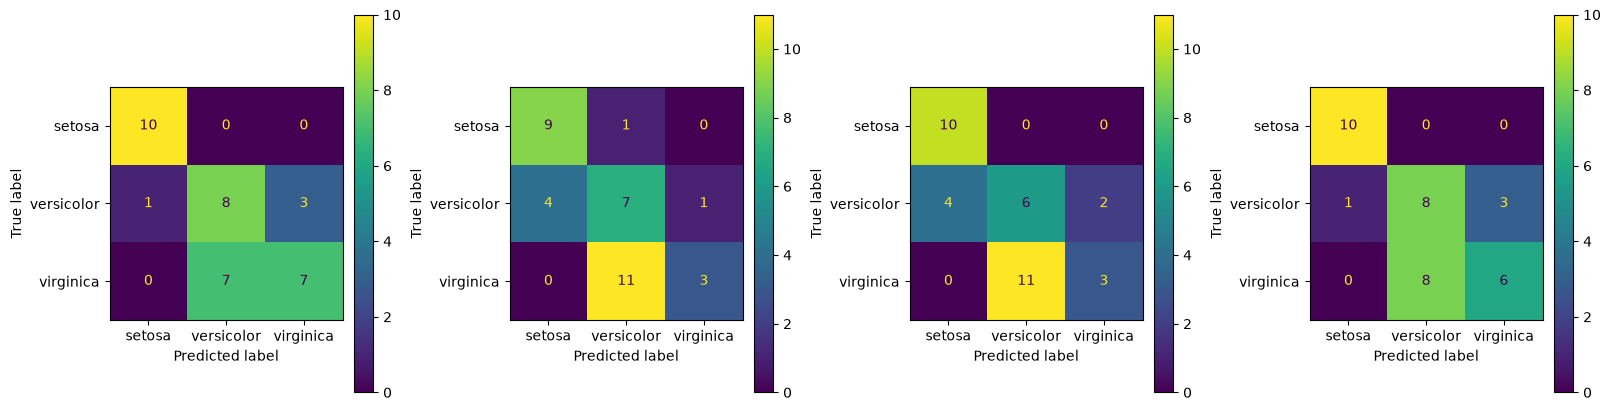

In [51]:
target_names_iris = ['setosa', 'versicolor', 'virginica']

cm1 = confusion_matrix(y_val, log_reg_pred)
cm2 = confusion_matrix(y_val, clf_pred)
cm3 = confusion_matrix(y_val, ran_pred)
cm4 = confusion_matrix(y_val,sm.predict(X_val))

fig, axs = plt.subplots(1, 4, figsize = (16, 4), layout='constrained')
ConfusionMatrixDisplay(cm1, display_labels = target_names_iris).plot(ax=axs[0])
ConfusionMatrixDisplay(cm2, display_labels = target_names_iris).plot(ax=axs[1])
ConfusionMatrixDisplay(cm3, display_labels = target_names_iris).plot(ax=axs[2])
ConfusionMatrixDisplay(cm4, display_labels = target_names_iris).plot(ax=axs[3])


In [43]:
print(classification_report(y_val, clf_pred, target_names=target_names_iris))

              precision    recall  f1-score   support

      setosa       0.69      0.90      0.78        10
  versicolor       0.37      0.58      0.45        12
   virginica       0.75      0.21      0.33        14

    accuracy                           0.53        36
   macro avg       0.60      0.57      0.52        36
weighted avg       0.61      0.53      0.50        36



In [44]:
print(classification_report(y_val, log_reg_pred, target_names=target_names_iris))

              precision    recall  f1-score   support

      setosa       0.91      1.00      0.95        10
  versicolor       0.53      0.67      0.59        12
   virginica       0.70      0.50      0.58        14

    accuracy                           0.69        36
   macro avg       0.71      0.72      0.71        36
weighted avg       0.70      0.69      0.69        36



In [45]:
print(classification_report(y_val, ran_pred, target_names=target_names_iris))

              precision    recall  f1-score   support

      setosa       0.71      1.00      0.83        10
  versicolor       0.35      0.50      0.41        12
   virginica       0.60      0.21      0.32        14

    accuracy                           0.53        36
   macro avg       0.56      0.57      0.52        36
weighted avg       0.55      0.53      0.49        36



In [52]:
print(classification_report(y_val, sm.predict(X_val), target_names=target_names_iris))

              precision    recall  f1-score   support

      setosa       0.91      1.00      0.95        10
  versicolor       0.50      0.67      0.57        12
   virginica       0.67      0.43      0.52        14

    accuracy                           0.67        36
   macro avg       0.69      0.70      0.68        36
weighted avg       0.68      0.67      0.66        36



# logitic regression is best

In [54]:
# Now we retrain our model on the train + validation data. 
log_reg_final = LogisticRegression().fit(X_train_full, y_train_full)
pred_test = log_reg_final.predict(X_test)

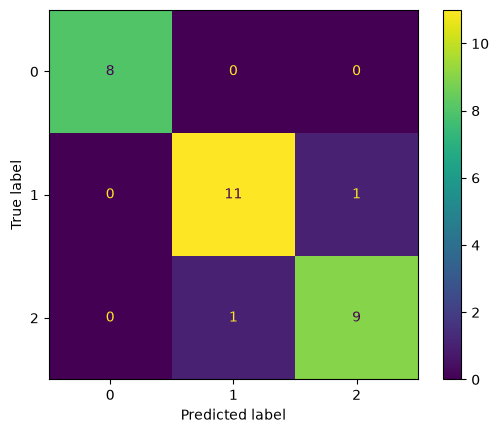

In [55]:
cm_test = confusion_matrix(y_test, pred_test)
ConfusionMatrixDisplay(cm_test).plot()